In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("results.csv")

print("Dataset Overview:")
print(df.head())
print("\nColumns:", df.columns.tolist())
print("\nShape:", df.shape)
print("\nNull counts:\n", df.isnull().sum())

Dataset Overview:
                 Parent_URL Page_Type  \
0  https://gtld-servers.net      Main   
1    https://googleapis.com      Main   
2      https://facebook.com      Main   
3      https://facebook.com     Login   
4      https://facebook.com  Register   

                                                 URL         COOP  \
0                           https://gtld-servers.net  Not present   
1                             https://googleapis.com  Not present   
2                               https://facebook.com  Not present   
3  https://facebook.com/recover/initiate/?privacy...  Not present   
4  https://facebook.com/reg/?entry_point=login&next=  Not present   

          COEP         CORP          CSP          XFO Iframe_Count  \
0  Not present  Not present  Not present  Not present  Not present   
1  Not present  Not present  Not present  Not present            0   
2  Not present  Not present  Not present  Not present            0   
3  Not present  Not present  Not present

# Isolation Rules Definition

## Rules for Browser Isolation Inconsistencies

These rules identify potential security vulnerabilities and inconsistencies in browser isolation implementations.

In [4]:
# Data Preparation: Convert "Not present" to NaN for easier boolean checks
df_clean = df.copy()
isolation_headers = ['COOP', 'COEP', 'CORP', 'CSP', 'XFO']
for col in isolation_headers:
    df_clean[col] = df_clean[col].replace('Not present', np.nan)

# Numeric columns for iframe analysis
df_clean['Iframe_Count'] = pd.to_numeric(df_clean['Iframe_Count'], errors='coerce')
df_clean['Cross_Origin_Iframes'] = pd.to_numeric(df_clean['Cross_Origin_Iframes'], errors='coerce')
df_clean['Sandboxed_Iframes'] = pd.to_numeric(df_clean['Sandboxed_Iframes'], errors='coerce')

print("Data prepared. Sample of cleaned data:")
print(df_clean[['COOP', 'COEP', 'CORP', 'Iframe_Count', 'Cross_Origin_Iframes', 'Sandboxed_Iframes']].head(10))

Data prepared. Sample of cleaned data:
  COOP COEP CORP  Iframe_Count  Cross_Origin_Iframes  Sandboxed_Iframes
0  NaN  NaN  NaN           NaN                   NaN                NaN
1  NaN  NaN  NaN           0.0                   0.0                0.0
2  NaN  NaN  NaN           0.0                   0.0                0.0
3  NaN  NaN  NaN           0.0                   0.0                0.0
4  NaN  NaN  NaN           0.0                   0.0                0.0
5  NaN  NaN  NaN           3.0                   0.0                1.0
6  NaN  NaN  NaN           2.0                   1.0                1.0
7  NaN  NaN  NaN           0.0                   0.0                0.0
8  NaN  NaN  NaN           0.0                   0.0                0.0
9  NaN  NaN  NaN           0.0                   0.0                0.0


### Rule 1: iframe sandboxing WITHOUT COOP/COEP
**Description:** Pages with sandboxed iframes but missing COOP/COEP headers lack fundamental process isolation.
**Risk:** Incomplete isolation - iframe sandboxing alone is insufficient without cross-origin policies.

### Rule 2: COEP enabled but cross-origin iframes without CORP
**Description:** COEP requires cross-origin resources to include CORP, but pages have cross-origin iframes without CORP headers.
**Risk:** COEP enforcement inconsistency - mixed signal of intent.

### Rule 3: Cross-origin iframes present but no sandboxing
**Description:** Multiple cross-origin iframes but none are sandboxed.
**Risk:** Untrusted third-party content runs with full privileges.

### Rule 4: No isolation headers + many cross-origin embeds
**Description:** No COOP/COEP/CSP headers combined with high cross-origin iframe count.
**Risk:** Permissive design with high third-party exposure.

### Rule 5: Conflicting signals - restrictive CSP/XFO but permissive iframe policy
**Description:** Has restrictive CSP or X-Frame-Options but allows multiple unsandboxed iframes.
**Risk:** Content restriction policy contradicts iframe trust model.

In [5]:
# RULE 1: iframe sandboxing WITHOUT COOP/COEP
# Sandboxed iframes exist but no COOP and no COEP
df_clean["rule1_violation"] = (
    (df_clean["Sandboxed_Iframes"] > 0) &
    (df_clean["COOP"].isnull()) &
    (df_clean["COEP"].isnull())
)

# RULE 2: COEP enabled but cross-origin iframes without CORP
# Has COEP but has cross-origin iframes and no CORP header
df_clean["rule2_violation"] = (
    (df_clean["COEP"].notna()) &
    (df_clean["Cross_Origin_Iframes"] > 0) &
    (df_clean["CORP"].isnull())
)

# RULE 3: Cross-origin iframes present but NO sandboxing
# Multiple cross-origin iframes but none are sandboxed
df_clean["rule3_violation"] = (
    (df_clean["Cross_Origin_Iframes"] > 0) &
    ((df_clean["Sandboxed_Iframes"] == 0) | (df_clean["Sandboxed_Iframes"].isnull()))
)

# RULE 4: No isolation headers + many cross-origin embeds
# Missing COOP, COEP, CSP and has significant cross-origin iframe presence
df_clean["rule4_violation"] = (
    (df_clean["COOP"].isnull()) &
    (df_clean["COEP"].isnull()) &
    (df_clean["CSP"].isnull()) &
    (df_clean["Cross_Origin_Iframes"] > 2)  # threshold: more than 2 cross-origin iframes
)

# RULE 5: Conflicting signals - restrictive CSP/XFO but permissive iframe policy
# Has restrictive headers but allows multiple unsandboxed cross-origin iframes
df_clean["rule5_violation"] = (
    ((df_clean["CSP"].notna()) | (df_clean["XFO"].notna())) &
    (df_clean["Cross_Origin_Iframes"] > 0) &
    ((df_clean["Sandboxed_Iframes"] == 0) | (df_clean["Sandboxed_Iframes"].isnull()) | 
     (df_clean["Sandboxed_Iframes"] < df_clean["Cross_Origin_Iframes"]))
)

print("Rules encoded successfully!")
print(f"\nRule Violations Summary:")
violations = df_clean[["rule1_violation", "rule2_violation", "rule3_violation", 
                        "rule4_violation", "rule5_violation"]].sum()
print(violations)
print(f"\nViolation Rates (%):")
print((violations / len(df_clean) * 100).round(2))

Rules encoded successfully!

Rule Violations Summary:
rule1_violation     896
rule2_violation       3
rule3_violation    1091
rule4_violation     291
rule5_violation     210
dtype: int64

Violation Rates (%):
rule1_violation    14.24
rule2_violation     0.05
rule3_violation    17.34
rule4_violation     4.63
rule5_violation     3.34
dtype: float64


# Statistical Analysis

## Prevalence of Isolation Mechanisms

In [6]:
# Create binary indicators for presence of headers
df_clean["has_coop"] = df_clean["COOP"].notna()
df_clean["has_coep"] = df_clean["COEP"].notna()
df_clean["has_corp"] = df_clean["CORP"].notna()
df_clean["has_csp"] = df_clean["CSP"].notna()
df_clean["has_xfo"] = df_clean["XFO"].notna()

print("=" * 60)
print("PREVALENCE OF ISOLATION MECHANISMS")
print("=" * 60)

prevalence = pd.DataFrame({
    "Mechanism": ["COOP", "COEP", "CORP", "CSP", "X-Frame-Options"],
    "Count": [
        df_clean["has_coop"].sum(),
        df_clean["has_coep"].sum(),
        df_clean["has_corp"].sum(),
        df_clean["has_csp"].sum(),
        df_clean["has_xfo"].sum()
    ]
})

prevalence["Percentage"] = (prevalence["Count"] / len(df_clean) * 100).round(2)
print(prevalence.to_string(index=False))

print("\n" + "=" * 60)
print("IFRAME STATISTICS")
print("=" * 60)

print(f"Pages with iframes: {(df_clean['Iframe_Count'] > 0).sum()} ({(df_clean['Iframe_Count'] > 0).mean() * 100:.2f}%)")
print(f"Pages with cross-origin iframes: {(df_clean['Cross_Origin_Iframes'] > 0).sum()} ({(df_clean['Cross_Origin_Iframes'] > 0).mean() * 100:.2f}%)")
print(f"Pages with sandboxed iframes: {(df_clean['Sandboxed_Iframes'] > 0).sum()} ({(df_clean['Sandboxed_Iframes'] > 0).mean() * 100:.2f}%)")

print(f"\nAverage iframes per page: {df_clean['Iframe_Count'].mean():.2f}")
print(f"Average cross-origin iframes per page: {df_clean['Cross_Origin_Iframes'].mean():.2f}")
print(f"Average sandboxed iframes per page: {df_clean['Sandboxed_Iframes'].mean():.2f}")

PREVALENCE OF ISOLATION MECHANISMS
      Mechanism  Count  Percentage
           COOP    236        3.75
           COEP    178        2.83
           CORP    200        3.18
            CSP    391        6.22
X-Frame-Options    792       12.59

IFRAME STATISTICS
Pages with iframes: 2628 (41.78%)
Pages with cross-origin iframes: 1808 (28.74%)
Pages with sandboxed iframes: 907 (14.42%)

Average iframes per page: 2.07
Average cross-origin iframes per page: 0.70
Average sandboxed iframes per page: 0.34


## Header Combinations (Critical for Paper)

In [7]:
# COOP × COEP combinations
print("\n" + "=" * 60)
print("COOP × COEP COMBINATIONS")
print("=" * 60)

combo_coop_coep = df_clean.groupby(["has_coop", "has_coep"]).size().reset_index(name="count")
combo_coop_coep["percentage"] = (combo_coop_coep["count"] / len(df_clean) * 100).round(2)
combo_coop_coep["coop_status"] = combo_coop_coep["has_coop"].map({True: "Has COOP", False: "No COOP"})
combo_coop_coep["coep_status"] = combo_coop_coep["has_coep"].map({True: "Has COEP", False: "No COEP"})
print(combo_coop_coep[["coop_status", "coep_status", "count", "percentage"]].to_string(index=False))

# All header combinations (top 10)
print("\n" + "=" * 60)
print("TOP 10 HEADER COMBINATIONS")
print("=" * 60)

combo_all = df_clean.groupby(["has_coop", "has_coep", "has_corp", "has_csp", "has_xfo"]).size().reset_index(name="count")
combo_all = combo_all.sort_values("count", ascending=False).head(10).reset_index(drop=True)
combo_all["percentage"] = (combo_all["count"] / len(df_clean) * 100).round(2)

for idx, row in combo_all.iterrows():
    headers = []
    if row["has_coop"]: headers.append("COOP")
    if row["has_coep"]: headers.append("COEP")
    if row["has_corp"]: headers.append("CORP")
    if row["has_csp"]: headers.append("CSP")
    if row["has_xfo"]: headers.append("XFO")
    
    header_str = ", ".join(headers) if headers else "No headers"
    print(f"{idx + 1}. {header_str}: {row['count']} sites ({row['percentage']}%)")


COOP × COEP COMBINATIONS
coop_status coep_status  count  percentage
    No COOP     No COEP   6054       96.25
   Has COOP     No COEP     58        0.92
   Has COOP    Has COEP    178        2.83

TOP 10 HEADER COMBINATIONS
1. No headers: 5353 sites (85.1%)
2. XFO: 342 sites (5.44%)
3. CSP, XFO: 225 sites (3.58%)
4. COOP, COEP, CORP, XFO: 155 sites (2.46%)
5. CSP: 115 sites (1.83%)
6. COOP, CSP, XFO: 21 sites (0.33%)
7. CORP: 16 sites (0.25%)
8. COOP, XFO: 15 sites (0.24%)
9. COOP, COEP, CORP, CSP, XFO: 11 sites (0.17%)
10. COOP, CORP, CSP, XFO: 7 sites (0.11%)


## Frequency of Inconsistencies

In [8]:
print("\n" + "=" * 60)
print("VIOLATION FREQUENCIES BY RULE")
print("=" * 60)

violations_summary = pd.DataFrame({
    "Rule": [
        "Rule 1: Sandboxed iframes WITHOUT COOP/COEP",
        "Rule 2: COEP + cross-origin iframes WITHOUT CORP",
        "Rule 3: Cross-origin iframes WITHOUT sandboxing",
        "Rule 4: No headers + many cross-origin embeds",
        "Rule 5: Conflicting signals (restrictive headers vs permissive iframes)"
    ],
    "Violations": [
        df_clean["rule1_violation"].sum(),
        df_clean["rule2_violation"].sum(),
        df_clean["rule3_violation"].sum(),
        df_clean["rule4_violation"].sum(),
        df_clean["rule5_violation"].sum()
    ]
})

violations_summary["Percentage"] = (violations_summary["Violations"] / len(df_clean) * 100).round(2)
print(violations_summary.to_string(index=False))

# Pages with multiple violations
print("\n" + "=" * 60)
print("MULTIPLE VIOLATIONS ANALYSIS")
print("=" * 60)

df_clean["violation_count"] = (df_clean["rule1_violation"].astype(int) + 
                                df_clean["rule2_violation"].astype(int) +
                                df_clean["rule3_violation"].astype(int) +
                                df_clean["rule4_violation"].astype(int) +
                                df_clean["rule5_violation"].astype(int))

for i in range(0, 6):
    count = (df_clean["violation_count"] == i).sum()
    pct = count / len(df_clean) * 100
    print(f"Pages with {i} violation(s): {count} ({pct:.2f}%)")


VIOLATION FREQUENCIES BY RULE
                                                                   Rule  Violations  Percentage
                            Rule 1: Sandboxed iframes WITHOUT COOP/COEP         896       14.24
                       Rule 2: COEP + cross-origin iframes WITHOUT CORP           3        0.05
                        Rule 3: Cross-origin iframes WITHOUT sandboxing        1091       17.34
                          Rule 4: No headers + many cross-origin embeds         291        4.63
Rule 5: Conflicting signals (restrictive headers vs permissive iframes)         210        3.34

MULTIPLE VIOLATIONS ANALYSIS
Pages with 0 violation(s): 4300 (68.36%)
Pages with 1 violation(s): 1502 (23.88%)
Pages with 2 violation(s): 475 (7.55%)
Pages with 3 violation(s): 13 (0.21%)
Pages with 4 violation(s): 0 (0.00%)
Pages with 5 violation(s): 0 (0.00%)


# Patterns & Correlation Analysis

## Third-Party Content Impact

In [9]:
# Analyze correlation between third-party embeds and violations
print("\n" + "=" * 60)
print("THIRD-PARTY CONTENT & VIOLATION CORRELATION")
print("=" * 60)

# Create third-party bucket
df_clean["third_party_bucket"] = pd.cut(df_clean["Cross_Origin_Iframes"], 
                                         bins=[-0.1, 0, 1, 5, 100], 
                                         labels=["0", "1", "2-5", "6+"])

print("\nRule violations by third-party iframe count:")
for rule in range(1, 6):
    col_name = f"rule{rule}_violation"
    print(f"\nRule {rule}:")
    by_bucket = df_clean.groupby("third_party_bucket")[col_name].agg(["sum", "count", "mean"])
    by_bucket.columns = ["Violations", "Total", "Percentage"]
    by_bucket["Percentage"] = (by_bucket["Percentage"] * 100).round(2)
    print(by_bucket)

# Overall isolation readiness
print("\n" + "=" * 60)
print("ISOLATION READINESS ASSESSMENT")
print("=" * 60)

# Strong isolation: has COOP + COEP
df_clean["strong_isolation"] = df_clean["has_coop"] & df_clean["has_coep"]

# Moderate isolation: has COOP or COEP
df_clean["moderate_isolation"] = (df_clean["has_coop"] | df_clean["has_coep"]) & ~df_clean["strong_isolation"]

# No isolation: neither COOP nor COEP
df_clean["no_isolation"] = ~(df_clean["has_coop"] | df_clean["has_coep"])

print(f"\nStrong isolation (COOP + COEP): {df_clean['strong_isolation'].sum()} ({df_clean['strong_isolation'].mean() * 100:.2f}%)")
print(f"Moderate isolation (COOP or COEP): {df_clean['moderate_isolation'].sum()} ({df_clean['moderate_isolation'].mean() * 100:.2f}%)")
print(f"No isolation: {df_clean['no_isolation'].sum()} ({df_clean['no_isolation'].mean() * 100:.2f}%)")

# Violation rates by isolation level
print("\n" + "=" * 60)
print("VIOLATION RATES BY ISOLATION LEVEL")
print("=" * 60)

for isolation_type, label in [("strong_isolation", "Strong"), ("moderate_isolation", "Moderate"), ("no_isolation", "None")]:
    subset = df_clean[df_clean[isolation_type]]
    if len(subset) > 0:
        print(f"\n{label} Isolation ({len(subset)} sites):")
        for rule in range(1, 6):
            col_name = f"rule{rule}_violation"
            rate = subset[col_name].mean() * 100
            print(f"  Rule {rule}: {rate:.2f}%")


THIRD-PARTY CONTENT & VIOLATION CORRELATION

Rule violations by third-party iframe count:

Rule 1:
                    Violations  Total  Percentage
third_party_bucket                               
0                          186   2983        6.24
1                          275   1098       25.05
2-5                        375    643       58.32
6+                          60     67       89.55

Rule 2:
                    Violations  Total  Percentage
third_party_bucket                               
0                            0   2983        0.00
1                            1   1098        0.09
2-5                          2    643        0.31
6+                           0     67        0.00

Rule 3:
                    Violations  Total  Percentage
third_party_bucket                               
0                            0   2983        0.00
1                          820   1098       74.68
2-5                        264    643       41.06
6+                           7  

## Behavior by Page Type

In [10]:
print("\n" + "=" * 60)
print("ISOLATION POLICIES BY PAGE TYPE")
print("=" * 60)

if "Page_Type" in df_clean.columns:
    page_types = df_clean["Page_Type"].value_counts()
    print(f"\nPage types in dataset:")
    print(page_types)
    
    print("\n" + "-" * 60)
    print("Header presence by page type:")
    page_type_analysis = df_clean.groupby("Page_Type")[["has_coop", "has_coep", "has_corp", "has_csp", "has_xfo"]].mean() * 100
    print(page_type_analysis.round(2))
    
    print("\n" + "-" * 60)
    print("Violation rates by page type:")
    for rule in range(1, 6):
        col_name = f"rule{rule}_violation"
        page_type_violations = df_clean.groupby("Page_Type")[col_name].mean() * 100
        print(f"\nRule {rule}:")
        print(page_type_violations.round(2))
else:
    print("Page_Type column not available in dataset")

# Save cleaned dataframe for later analysis
print("\n" + "=" * 60)
print("Data preparation complete!")
print(f"Total pages analyzed: {len(df_clean)}")
print(f"Columns: {list(df_clean.columns)}")


ISOLATION POLICIES BY PAGE TYPE

Page types in dataset:
Page_Type
Main        5000
Login        860
Register     430
Name: count, dtype: int64

------------------------------------------------------------
Header presence by page type:
           has_coop  has_coep  has_corp  has_csp  has_xfo
Page_Type                                                
Login          3.49      1.74      2.33     9.42    16.63
Main           3.74      3.00      3.36     5.28    11.30
Register       4.42      3.02      2.79    10.70    19.53

------------------------------------------------------------
Violation rates by page type:

Rule 1:
Page_Type
Login       18.49
Main        12.50
Register    26.05
Name: rule1_violation, dtype: float64

Rule 2:
Page_Type
Login       0.12
Main        0.02
Register    0.23
Name: rule2_violation, dtype: float64

Rule 3:
Page_Type
Login       30.93
Main        14.56
Register    22.56
Name: rule3_violation, dtype: float64

Rule 4:
Page_Type
Login       5.35
Main        4.44

# Visualizations

## Setup Visualization Libraries

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

### Fig 1: Adoption of Isolation Headers

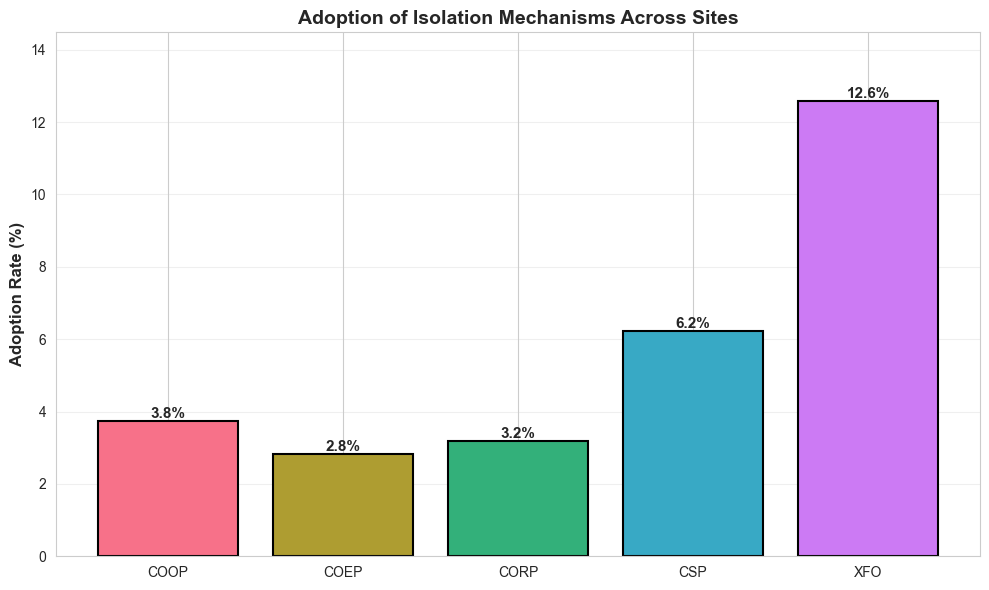

Figure 1 displayed: Adoption rates show which isolation mechanisms are most commonly deployed.


In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

mechanisms = ["COOP", "COEP", "CORP", "CSP", "XFO"]
adoption_rates = [
    df_clean["has_coop"].mean() * 100,
    df_clean["has_coep"].mean() * 100,
    df_clean["has_corp"].mean() * 100,
    df_clean["has_csp"].mean() * 100,
    df_clean["has_xfo"].mean() * 100
]

colors = sns.color_palette("husl", len(mechanisms))
bars = ax.bar(mechanisms, adoption_rates, color=colors, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Adoption Rate (%)', fontsize=12, fontweight='bold')
ax.set_title('Adoption of Isolation Mechanisms Across Sites', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(adoption_rates) * 1.15)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Figure 1 displayed: Adoption rates show which isolation mechanisms are most commonly deployed.")

### Fig 2: COOP × COEP Deployment Matrix

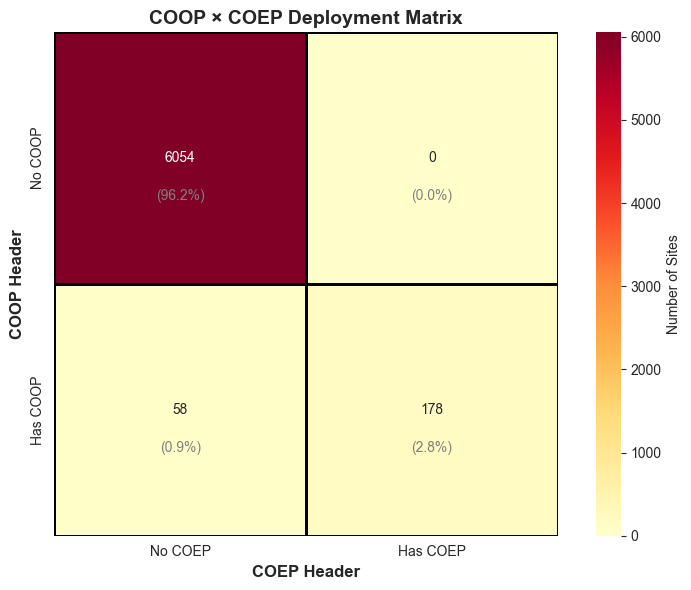

Figure 2 displayed: Shows how COOP and COEP are deployed together (or not).


In [13]:
fig, ax = plt.subplots(figsize=(8, 6))

# Create contingency table
coop_coep_matrix = pd.crosstab(df_clean["has_coop"], df_clean["has_coep"], margins=False)
coop_coep_matrix.index = ["No COOP", "Has COOP"]
coop_coep_matrix.columns = ["No COEP", "Has COEP"]

# Create heatmap with annotations
sns.heatmap(coop_coep_matrix, annot=True, fmt='d', cmap='YlOrRd', 
            cbar_kws={'label': 'Number of Sites'}, ax=ax, 
            linewidths=2, linecolor='black', square=True)

ax.set_title('COOP × COEP Deployment Matrix', fontsize=14, fontweight='bold')
ax.set_ylabel('COOP Header', fontsize=12, fontweight='bold')
ax.set_xlabel('COEP Header', fontsize=12, fontweight='bold')

# Add percentages as text annotations
total = coop_coep_matrix.sum().sum()
for i in range(len(coop_coep_matrix)):
    for j in range(len(coop_coep_matrix.columns)):
        count = coop_coep_matrix.iloc[i, j]
        pct = count / total * 100
        ax.text(j + 0.5, i + 0.65, f'({pct:.1f}%)', 
               ha='center', va='center', fontsize=10, color='gray')

plt.tight_layout()
plt.show()

print("Figure 2 displayed: Shows how COOP and COEP are deployed together (or not).")

### Fig 3: Violation Frequency by Rule

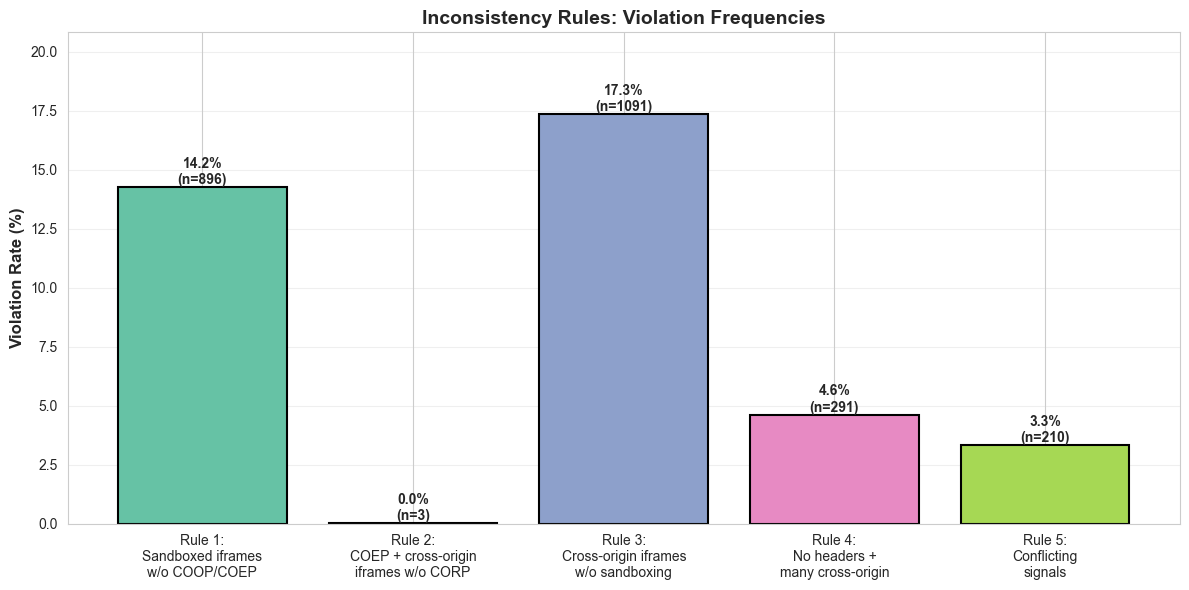

Figure 3 displayed: Isolation inconsistency rule violations across the dataset.


In [14]:
fig, ax = plt.subplots(figsize=(12, 6))

rule_names = [
    "Rule 1:\nSandboxed iframes\nw/o COOP/COEP",
    "Rule 2:\nCOEP + cross-origin\niframes w/o CORP",
    "Rule 3:\nCross-origin iframes\nw/o sandboxing",
    "Rule 4:\nNo headers +\nmany cross-origin",
    "Rule 5:\nConflicting\nsignals"
]

violation_counts = [
    df_clean["rule1_violation"].sum(),
    df_clean["rule2_violation"].sum(),
    df_clean["rule3_violation"].sum(),
    df_clean["rule4_violation"].sum(),
    df_clean["rule5_violation"].sum()
]

violation_rates = [(v / len(df_clean) * 100) for v in violation_counts]

colors_violations = sns.color_palette("Set2", len(rule_names))
bars = ax.bar(range(len(rule_names)), violation_rates, color=colors_violations, 
              edgecolor='black', linewidth=1.5)

# Add value labels and counts on bars
for i, (bar, count, rate) in enumerate(zip(bars, violation_counts, violation_rates)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{rate:.1f}%\n(n={count})',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(range(len(rule_names)))
ax.set_xticklabels(rule_names, fontsize=10)
ax.set_ylabel('Violation Rate (%)', fontsize=12, fontweight='bold')
ax.set_title('Inconsistency Rules: Violation Frequencies', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(violation_rates) * 1.2)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Figure 3 displayed: Isolation inconsistency rule violations across the dataset.")

### Fig 4: Rule Violation Correlation Heatmap

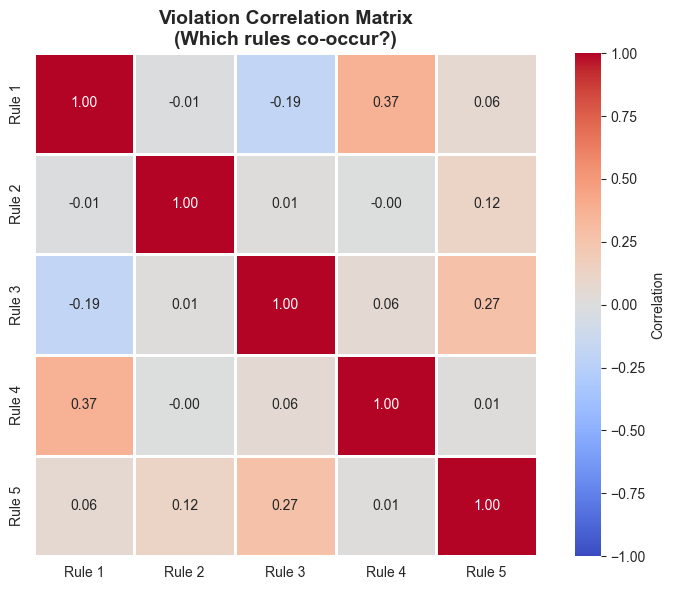

Figure 4 displayed: Correlation between rule violations shows which inconsistencies tend to occur together.


In [15]:
fig, ax = plt.subplots(figsize=(8, 6))

# Create correlation matrix for rule violations
rules_data = df_clean[[
    "rule1_violation", "rule2_violation", "rule3_violation",
    "rule4_violation", "rule5_violation"
]].astype(int)

rules_data.columns = ["Rule 1", "Rule 2", "Rule 3", "Rule 4", "Rule 5"]
correlation_matrix = rules_data.corr()

# Create heatmap
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=2, cbar_kws={'label': 'Correlation'},
            vmin=-1, vmax=1, ax=ax)

ax.set_title('Violation Correlation Matrix\n(Which rules co-occur?)', 
            fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("Figure 4 displayed: Correlation between rule violations shows which inconsistencies tend to occur together.")

### Fig 5: Isolation Readiness Levels

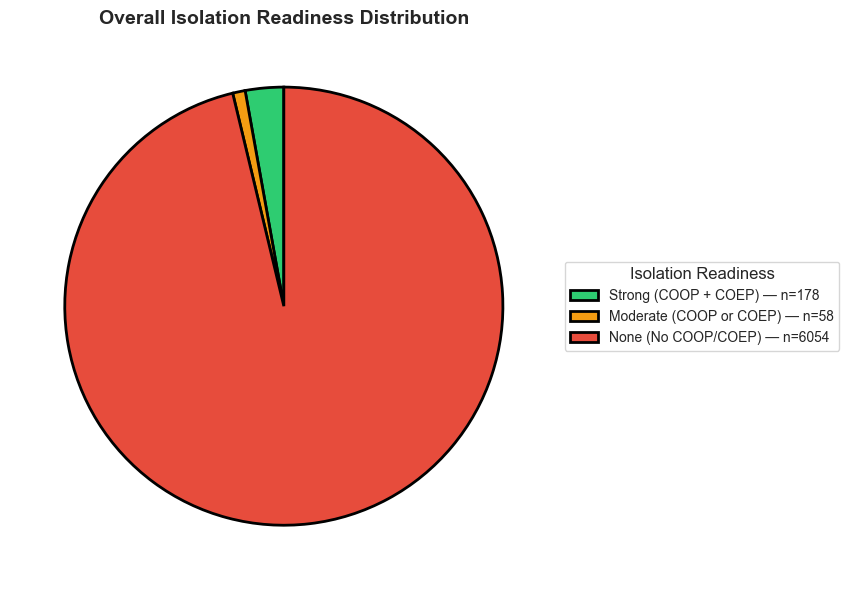

Figure 5 displayed: Sites categorized by their isolation readiness level.


In [23]:
fig, ax = plt.subplots(figsize=(10, 6))

isolation_counts = [
    df_clean["strong_isolation"].sum(),
    df_clean["moderate_isolation"].sum(),
    df_clean["no_isolation"].sum()
]

isolation_labels = [
    f"Strong\n(COOP + COEP)\nn={isolation_counts[0]}",
    f"Moderate\n(COOP or COEP)\nn={isolation_counts[1]}",
    f"None\n(No COOP/COEP)\nn={isolation_counts[2]}"
]

isolation_pcts = [c / len(df_clean) * 100 for c in isolation_counts]
colors_isolation = ['#2ecc71', '#f39c12', '#e74c3c']

pie_result = ax.pie(isolation_pcts, labels=None,
                    colors=colors_isolation, startangle=90,
                    textprops={'fontsize': 11, 'fontweight': 'bold'},
                    wedgeprops={'edgecolor': 'black', 'linewidth': 2})

# matplotlib can return 2 or 3 items depending on version
if len(pie_result) == 3:
    wedges, texts, autotexts = pie_result
else:
    wedges, texts = pie_result
    autotexts = []

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')

legend_labels = [
    f"Strong (COOP + COEP) — n={isolation_counts[0]}",
    f"Moderate (COOP or COEP) — n={isolation_counts[1]}",
    f"None (No COOP/COEP) — n={isolation_counts[2]}"
]
ax.legend(wedges, legend_labels, title='Isolation Readiness', loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10, title_fontsize=12)
ax.set_title('Overall Isolation Readiness Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("Figure 5 displayed: Sites categorized by their isolation readiness level.")

### Fig 6: Third-Party Content & Violation Risk

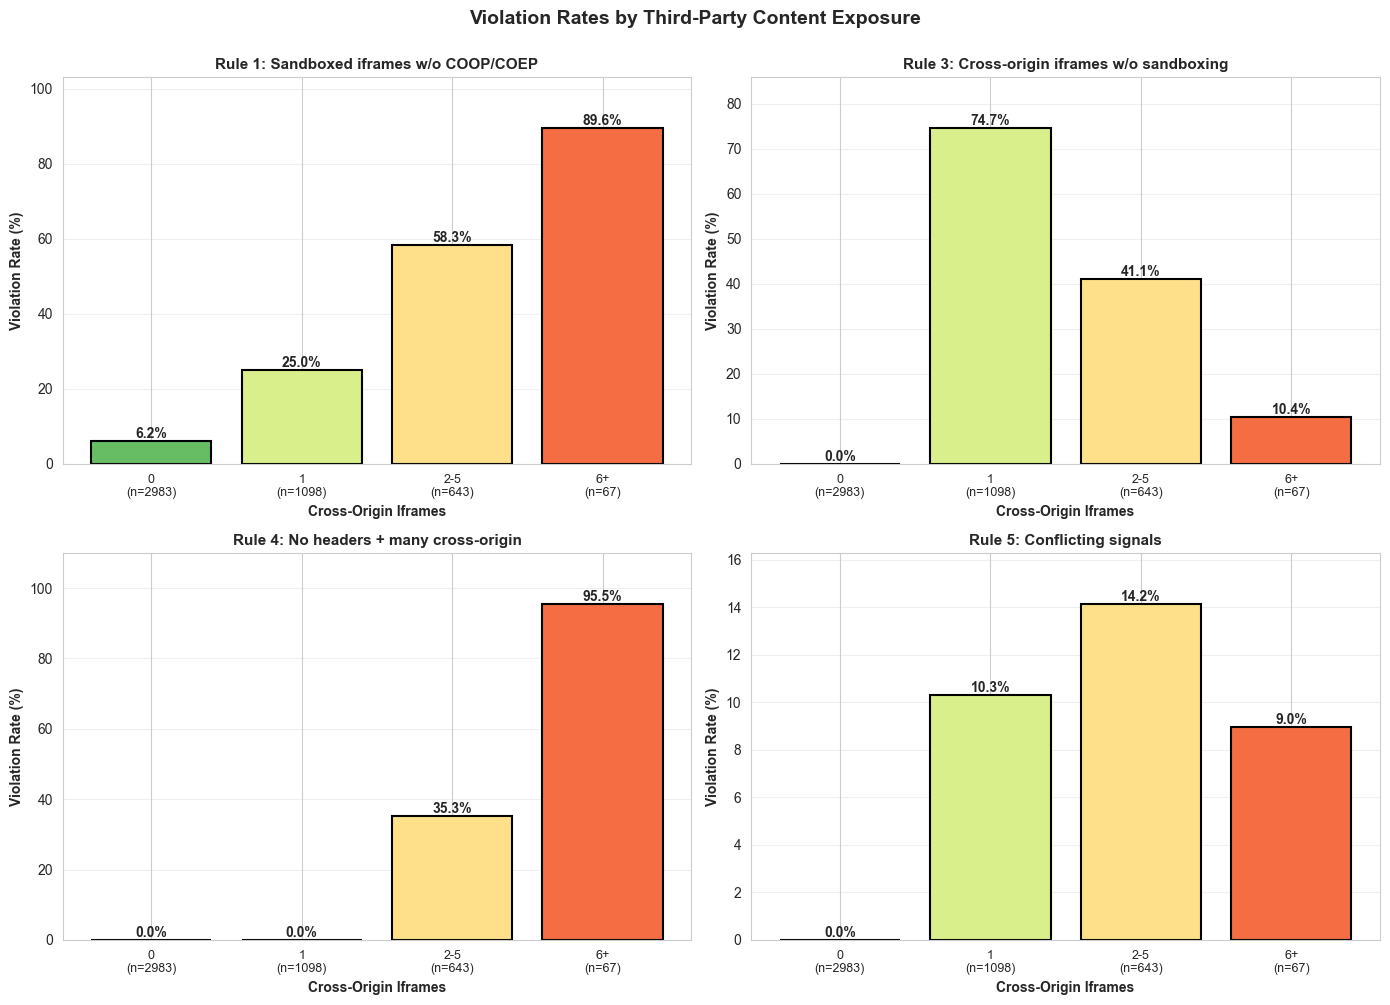

Figure 6 displayed: How third-party iframe count correlates with violation risk.


In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# For each major rule, show violation rate by third-party bucket
rule_configs = [
    ("rule1_violation", "Rule 1: Sandboxed iframes w/o COOP/COEP"),
    ("rule3_violation", "Rule 3: Cross-origin iframes w/o sandboxing"),
    ("rule4_violation", "Rule 4: No headers + many cross-origin"),
    ("rule5_violation", "Rule 5: Conflicting signals")
]

for idx, (rule_col, rule_label) in enumerate(rule_configs):
    ax = axes[idx]
    
    # Calculate violation rate by third-party bucket
    bucket_rates = []
    bucket_labels = []
    bucket_counts = []
    
    for bucket in ["0", "1", "2-5", "6+"]:
        subset = df_clean[df_clean["third_party_bucket"] == bucket]
        if len(subset) > 0:
            rate = subset[rule_col].mean() * 100
            count = len(subset)
            bucket_rates.append(rate)
            bucket_labels.append(f"{bucket}\n(n={count})")
            bucket_counts.append(count)
    
    colors_bkt = sns.color_palette("RdYlGn_r", len(bucket_rates))
    bars = ax.bar(range(len(bucket_labels)), bucket_rates, color=colors_bkt, 
                  edgecolor='black', linewidth=1.5)
    
    # Add labels on bars
    for bar, rate in zip(bars, bucket_rates):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{rate:.1f}%',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax.set_xticks(range(len(bucket_labels)))
    ax.set_xticklabels(bucket_labels, fontsize=9)
    ax.set_ylabel('Violation Rate (%)', fontsize=10, fontweight='bold')
    ax.set_xlabel('Cross-Origin Iframes', fontsize=10, fontweight='bold')
    ax.set_title(rule_label, fontsize=11, fontweight='bold')
    ax.set_ylim(0, max(bucket_rates) * 1.15)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Violation Rates by Third-Party Content Exposure', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("Figure 6 displayed: How third-party iframe count correlates with violation risk.")

### Fig 7: Multiple Violation Distribution

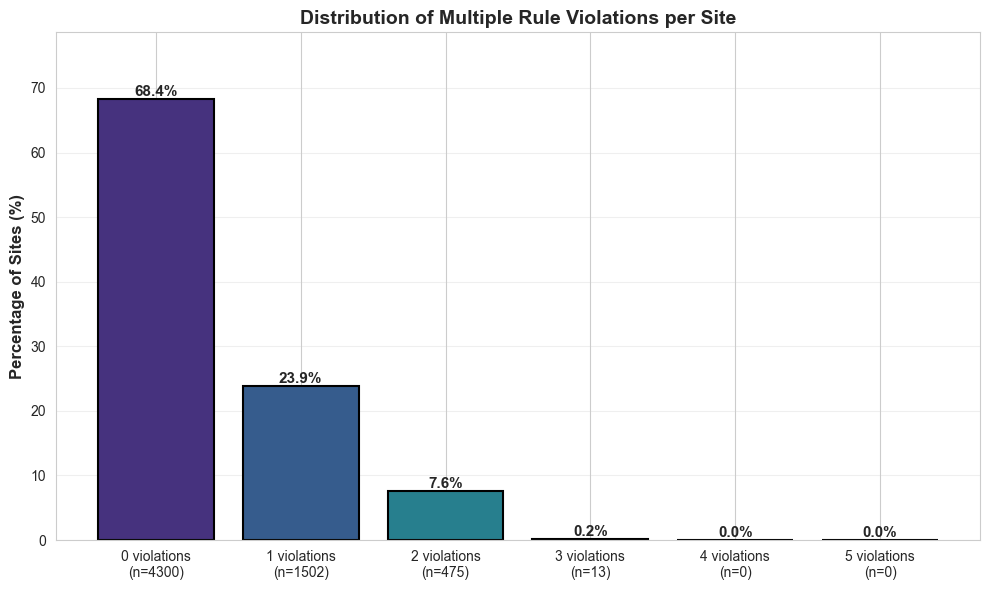

Figure 7 displayed: Shows how many sites have multiple isolation inconsistencies.


In [18]:
fig, ax = plt.subplots(figsize=(10, 6))

violation_dist = []
violation_dist_labels = []
violation_dist_counts = []

for i in range(0, 6):
    count = (df_clean["violation_count"] == i).sum()
    pct = count / len(df_clean) * 100
    violation_dist.append(pct)
    violation_dist_labels.append(f"{i} violations\n(n={count})")
    violation_dist_counts.append(count)

colors_vd = sns.color_palette("viridis", len(violation_dist))
bars = ax.bar(range(len(violation_dist)), violation_dist, color=colors_vd,
              edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar, pct in zip(bars, violation_dist):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{pct:.1f}%',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xticks(range(len(violation_dist_labels)))
ax.set_xticklabels(violation_dist_labels, fontsize=10)
ax.set_ylabel('Percentage of Sites (%)', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Multiple Rule Violations per Site', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(violation_dist) * 1.15)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Figure 7 displayed: Shows how many sites have multiple isolation inconsistencies.")

# Summary & Key Findings

## Analysis Complete

This analysis defined 5 critical isolation rules for detecting browser isolation inconsistencies in real-world websites and measured their prevalence across your dataset.

In [19]:
print("\n" + "=" * 70)
print("KEY FINDINGS SUMMARY")
print("=" * 70)

print("\n1. HEADER ADOPTION")
print("-" * 70)
print(f"   • COOP deployed: {df_clean['has_coop'].mean() * 100:.1f}% of sites")
print(f"   • COEP deployed: {df_clean['has_coep'].mean() * 100:.1f}% of sites")
print(f"   • Both COOP + COEP: {(df_clean['has_coop'] & df_clean['has_coep']).mean() * 100:.1f}% of sites")
print(f"   → Many sites lack fundamental process isolation headers")

print("\n2. IFRAME LANDSCAPE")
print("-" * 70)
print(f"   • Sites with iframes: {(df_clean['Iframe_Count'] > 0).mean() * 100:.1f}%")
print(f"   • Sites with cross-origin iframes: {(df_clean['Cross_Origin_Iframes'] > 0).mean() * 100:.1f}%")
print(f"   • Sites with sandboxed iframes: {(df_clean['Sandboxed_Iframes'] > 0).mean() * 100:.1f}%")
print(f"   → High third-party exposure but limited use of sandbox mechanism")

print("\n3. VIOLATION PREVALENCE")
print("-" * 70)
for rule in range(1, 6):
    col_name = f"rule{rule}_violation"
    count = df_clean[col_name].sum()
    rate = count / len(df_clean) * 100
    print(f"   • Rule {rule}: {rate:.1f}% of sites ({count} sites)")

print("\n4. MULTIPLE INCONSISTENCIES")
print("-" * 70)
clean_sites = (df_clean["violation_count"] == 0).sum()
any_violations = (df_clean["violation_count"] > 0).sum()
multi_violations = (df_clean["violation_count"] > 1).sum()
print(f"   • Sites with NO violations: {clean_sites / len(df_clean) * 100:.1f}%")
print(f"   • Sites with ANY violation: {any_violations / len(df_clean) * 100:.1f}%")
print(f"   • Sites with 2+ violations: {multi_violations / len(df_clean) * 100:.1f}%")
print(f"   → Many sites exhibit multiple inconsistencies simultaneously")

print("\n5. ISOLATION READINESS")
print("-" * 70)
print(f"   • Strong isolation (COOP + COEP): {df_clean['strong_isolation'].mean() * 100:.1f}%")
print(f"   • Moderate isolation: {df_clean['moderate_isolation'].mean() * 100:.1f}%")
print(f"   • No isolation: {df_clean['no_isolation'].mean() * 100:.1f}%")

print("\n" + "=" * 70)
print(f"Total sites analyzed: {len(df_clean)}")
print("=" * 70)


KEY FINDINGS SUMMARY

1. HEADER ADOPTION
----------------------------------------------------------------------
   • COOP deployed: 3.8% of sites
   • COEP deployed: 2.8% of sites
   • Both COOP + COEP: 2.8% of sites
   → Many sites lack fundamental process isolation headers

2. IFRAME LANDSCAPE
----------------------------------------------------------------------
   • Sites with iframes: 41.8%
   • Sites with cross-origin iframes: 28.7%
   • Sites with sandboxed iframes: 14.4%
   → High third-party exposure but limited use of sandbox mechanism

3. VIOLATION PREVALENCE
----------------------------------------------------------------------
   • Rule 1: 14.2% of sites (896 sites)
   • Rule 2: 0.0% of sites (3 sites)
   • Rule 3: 17.3% of sites (1091 sites)
   • Rule 4: 4.6% of sites (291 sites)
   • Rule 5: 3.3% of sites (210 sites)

4. MULTIPLE INCONSISTENCIES
----------------------------------------------------------------------
   • Sites with NO violations: 68.4%
   • Sites with AN